## Multiple and Logistic Regrssion Case Study

In [7]:
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

### Problem

Your task is to use California census data to build a model of housing prices in the state. This data includes metrics such as the **population**, **median** **income**, and **median housing price** for each block group (district) in California. Your model should learn from this data and be able to **predict the median housing price** in any district, given all the other metrics.

#### Steps to frame the problem

##### 1- understand the problem: To understand the problem we need to understand the data

In [17]:
housing = pd.read_csv("Cal_Housing.csv")
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


The dataset includes **10 attributes** describing **20,640 districts**

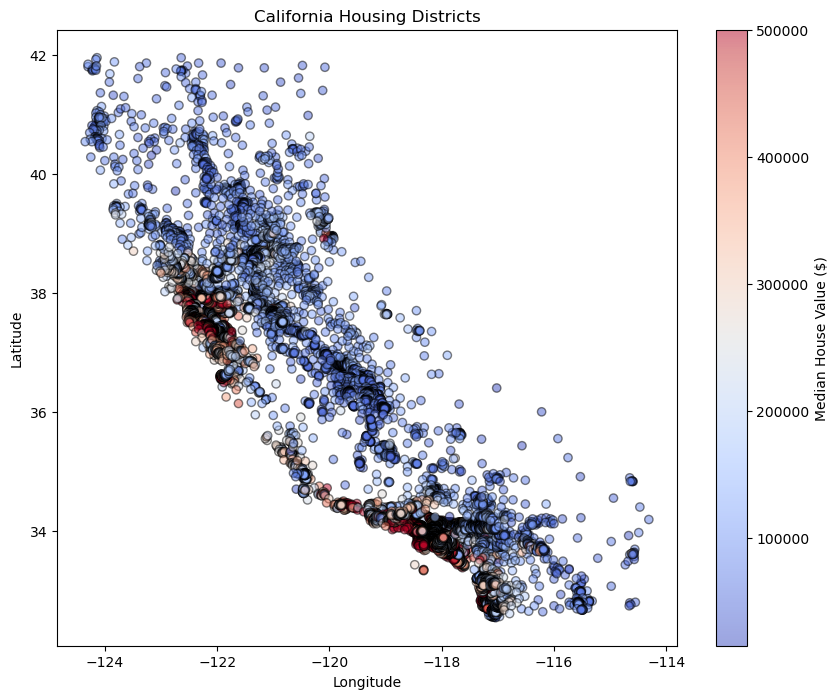

In [18]:
plt.figure(figsize=(10, 8))
plt.scatter(housing["longitude"], housing["latitude"], c=housing["median_house_value"], cmap="coolwarm", alpha=0.5, edgecolors="k")

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("California Housing Districts")
plt.colorbar(label="Median House Value ($)")

plt.show()

In [19]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [20]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [21]:
missing_values = housing.isnull().sum()
print(missing_values[missing_values > 0])

total_bedrooms    207
dtype: int64


In [23]:
housing["total_bedrooms"] = housing["total_bedrooms"].fillna(housing["total_bedrooms"].median())
print(housing.isnull().sum())

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64


In [24]:
housing["ocean_proximity"].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

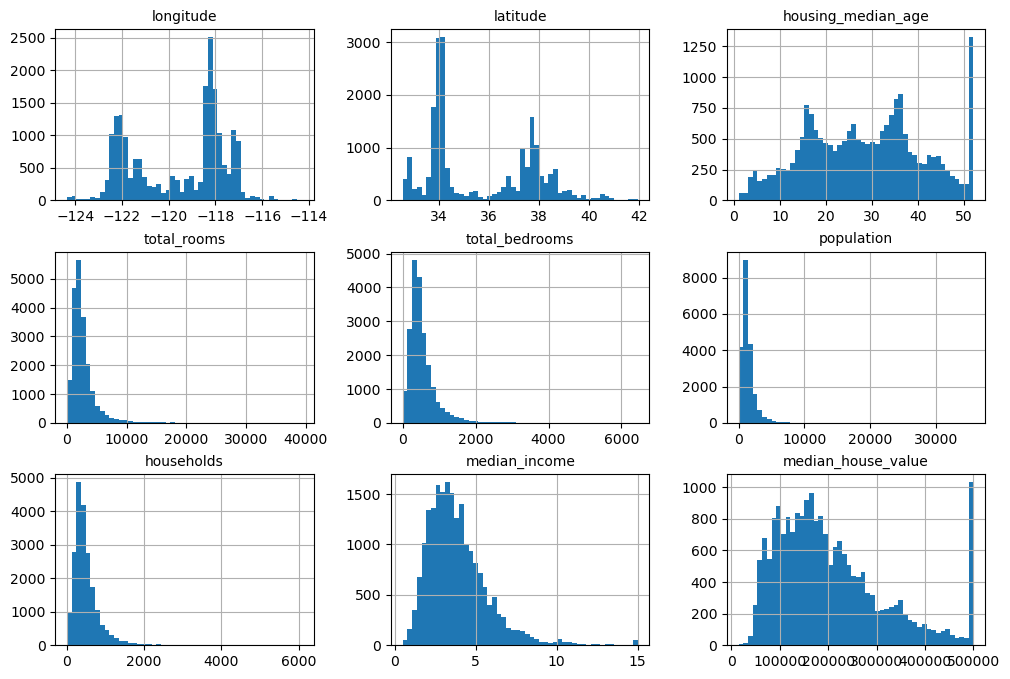

In [25]:
plt.rc('font', size=10)
plt.rc('axes', labelsize=10, titlesize=10)
plt.rc('legend', fontsize=10)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

housing.hist(bins=50, figsize=(12, 8))
plt.show()

##### 2- Create the model: decide on the training and set datasets

Sampling is a big issue in training the model, that is why we have many ways to draw samples. 
We want to create a **stratified sample** which is representative of all categories. What categories do we have?

In [89]:
housing["house_value_cat"] = pd.cut(housing["median_house_value"],
                                    bins=[0, 150000, 300000, 450000, 600000, np.inf],
                                    labels=[1, 2, 3, 4, 5])
print(housing["house_value_cat"].value_counts())

house_value_cat
2    9184
1    7620
3    2579
4    1257
5       0
Name: count, dtype: int64


In [33]:
strat_train_set, strat_test_set = train_test_split(housing, test_size=0.2, stratify=housing["house_value_cat"], random_state=42)

In [34]:
for set_ in (strat_train_set, strat_test_set):
    set_.drop("house_value_cat", axis=1, inplace=True)

Now we have a **training set** (strat_train_set) and a **testing set** (strat_test_set)

##### 3- Find correlations, if any.

In [37]:
numeric_housing = housing.select_dtypes(include=[np.number])
corr_matrix = numeric_housing.corr()
print(corr_matrix)

                    longitude  latitude  housing_median_age  total_rooms  \
longitude            1.000000 -0.924664           -0.108197     0.044568   
latitude            -0.924664  1.000000            0.011173    -0.036100   
housing_median_age  -0.108197  0.011173            1.000000    -0.361262   
total_rooms          0.044568 -0.036100           -0.361262     1.000000   
total_bedrooms       0.069120 -0.066484           -0.319026     0.927058   
population           0.099773 -0.108785           -0.296244     0.857126   
households           0.055310 -0.071035           -0.302916     0.918484   
median_income       -0.015176 -0.079809           -0.119034     0.198050   
median_house_value  -0.045967 -0.144160            0.105623     0.134153   

                    total_bedrooms  population  households  median_income  \
longitude                 0.069120    0.099773    0.055310      -0.015176   
latitude                 -0.066484   -0.108785   -0.071035      -0.079809   
housing_

In [38]:
corr_matrix["median_house_value"].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049457
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64

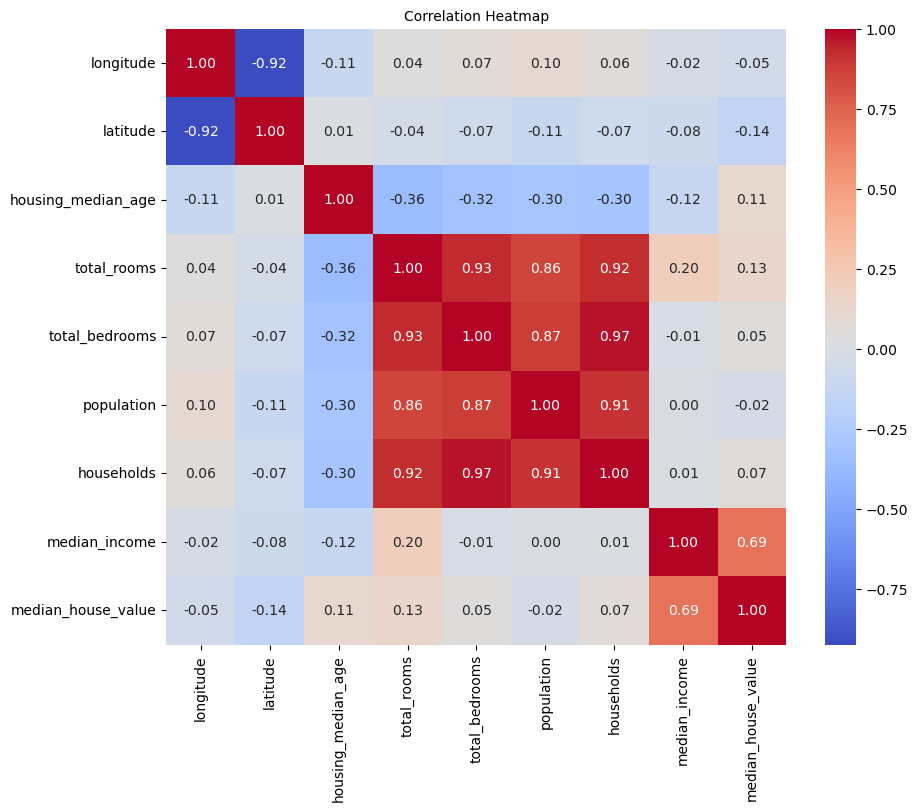

In [39]:
import seaborn as sns
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

##### 3.1 Median Income and Median House value.

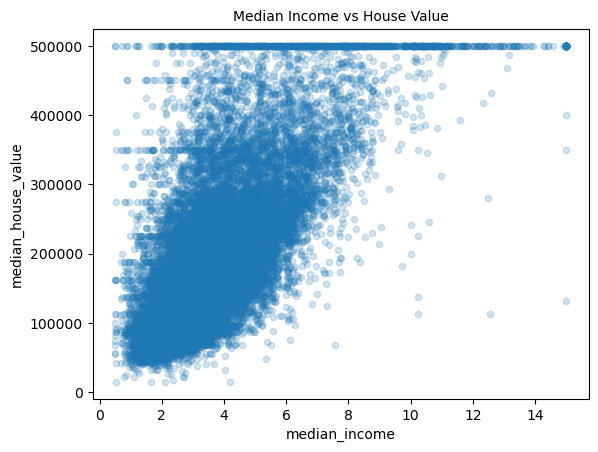

In [40]:
housing.plot(kind="scatter", x="median_income", y="median_house_value", alpha=0.2)
plt.title("Median Income vs House Value")
plt.show()

**median_income** is a strong predictor of house value, so we will keep it. 

##### 3.2 Total Rooms and Total Bedrooms
Since the variables are highly correlated, we have multiple options:  
1- Experiment and produce new features that may be more useful, if not  
2- Drop one of them.  

Generate new feature **Feature Engineering**

Bedrooms per Room Ratio  
A house with many rooms but few bedrooms might be an apartment, while a high bedrooms/rooms ratio might indicate a lower-income area.  

In [41]:
housing["bedrooms_per_room"] = housing["total_bedrooms"] / housing["total_rooms"]

##### 3.3 Rooms per House
The number of rooms per household can be a strong indicator of housing quality.

In [42]:
housing["rooms_per_household"] = housing["total_rooms"] / housing["households"]

##### 3.4 Bedrooms per House
The number of bedrooms per household could indicate multi-family housing

In [44]:
housing["bedrooms_per_household"] = housing["total_bedrooms"] / housing["households"]

##### 4. Train the model

This is a **supervised problem** and the outcome is continous, then one way to solve it is **Regression**.  
Linear Regression accept numerical data **ONLY**

##### 4.1 We need to prepare the data before training the model

We have a Categorical attribute **(NEAR OCEAN)**  
Using One-Hot Encoding

In [55]:
housing = pd.get_dummies(housing, columns=["ocean_proximity"], drop_first=True)

##### 4.2 Train the model without the new features.

In [63]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error

In [64]:
housing_no_new = housing.drop(["median_house_value", "bedrooms_per_room", "rooms_per_household", "bedrooms_per_household"], axis=1)
y=housing["median_house_value"]
X_train_no, X_test_no, y_train_no, y_test_no = train_test_split(housing_no_new, y, test_size=0.2, random_state=42)

In [65]:
lin_reg_no = LinearRegression()
lin_reg_no.fit(X_train_no, y_train_no)

LinearRegression()

In [66]:
y_pred_test_no = lin_reg_no.predict(X_test_no)
test_rmse_no = root_mean_squared_error(y_test_no, y_pred_test_no)

print(f"Test RMSE (No New Features): {test_rmse_no}")

Test RMSE (No New Features): 34623.46469563423


In [67]:
housing["median_house_value"].describe()

count     20640.000000
mean     206855.816909
std      115395.615874
min       14999.000000
25%      119600.000000
50%      179700.000000
75%      264725.000000
max      500001.000000
Name: median_house_value, dtype: float64

##### 4.3 Train the model with the new Features

In [69]:
housing_with_new = housing.drop(["median_house_value"], axis=1)
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(housing_with_new, y, test_size=0.2, random_state=42)

In [70]:
lin_reg_new = LinearRegression()
lin_reg_new.fit(X_train_new, y_train_new)

LinearRegression()

In [75]:
y_pred_train_new = lin_reg_new.predict(X_train_new)
train_rmse_new = root_mean_squared_error(y_train_new, y_pred_train_new)

print(f"Test RMSE (With New Features): {train_rmse_new }")

Test RMSE (With New Features): 34115.28907164779


#### Creating a Logistic Model for Housing Data

To make the dataset applicable for logistic modeling, we will  
1- convert median_house_value into two categories: Affordable =0, Expensive=1  
2- use the other features to predict whether a house is Affordable or Expensive

In [76]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report



,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,house_value_cat,bedrooms_per_room,rooms_per_household,bedrooms_per_household,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,4,0.146591,6.984127,1.023810,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,3,0.155797,6.238137,0.971880,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,3,0.129516,8.288136,1.073446,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,3,0.184458,5.817352,1.073059,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,3,0.172096,6.281853,1.081081,False,False,True,False


In [77]:
threshold = housing["median_house_value"].median()

housing["house_category"] = (housing["median_house_value"] > threshold).astype(int)

X = housing.drop(["median_house_value", "house_category"], axis=1)
y = housing["house_category"]

In [78]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [87]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=5000, solver="lbfgs")
log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=5000)

In [88]:
y_pred_scaled = log_reg.predict(X_test_scaled)
accuracy_scaled = accuracy_score(y_test, y_pred_scaled)
print("Logistic Regression Accuracy:", accuracy_scaled)

Logistic Regression Accuracy: 0.8844476744186046
